# 05 - LSTM Model

LSTM (Long Short-Term Memory) for text sentiment classification.
This model uses the text reviews to classify sentiment (positive, neutral, negative).

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

print('Libraries imported')

I0000 00:00:1775601037.299842   81902 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775601037.381900   81902 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775601039.165918   81902 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Libraries imported


## Load Preprocessed Text Data

In [2]:
# Load preprocessed text data
X_train = np.load('dataset/processed/X_text_train.npy')
X_test = np.load('dataset/processed/X_text_test.npy')
y_train = np.load('dataset/processed/y_text_train.npy')
y_test = np.load('dataset/processed/y_text_test.npy')

print(f'Training shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

Training shape: (120, 100)
Test shape: (30, 100)


## Build LSTM Model

Bidirectional LSTM with:
- Embedding layer for word representations
- Bidirectional LSTM layers to capture context from both directions
- Dropout for regularization
- Dense output layer for multi-class classification

Architecture justification:
- Embedding(5000, 64): maps 5000-word vocabulary to 64-dim dense vectors
  - 64 dims balance expressiveness vs. overfitting on small dataset
- Bidirectional(LSTM(64)): processes text forwards AND backwards
  - return_sequences=True feeds full sequence to next LSTM layer
  - Bidirectional doubles context captured vs. unidirectional
- Dropout(0.5): strong regularization for small 120-sample training set
- Bidirectional(LSTM(32)): second layer captures higher-level patterns
- Dropout(0.3): mild regularization on deeper features
- Dense(32, ReLU): learns non-linear combinations of LSTM outputs
- Dense(3, Softmax): 3-class sentiment (positive/neutral/negative)

In [3]:
# Build LSTM model
vocab_size = 5000
embedding_dim = 64
max_len = 100

model = Sequential([
    Embedding(vocab_size, embedding_dim),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

E0000 00:00:1775601041.718435   81902 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Train Model

In [4]:
# Train model
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 473ms/step - accuracy: 0.3438 - loss: 1.0907 - val_accuracy: 0.5833 - val_loss: 1.0490
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.5833 - loss: 1.0312 - val_accuracy: 0.5417 - val_loss: 0.9540
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.4792 - loss: 0.9519 - val_accuracy: 0.5417 - val_loss: 0.8189
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.4688 - loss: 0.8847 - val_accuracy: 1.0000 - val_loss: 0.7359
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.4583 - loss: 0.8464 - val_accuracy: 0.4583 - val_loss: 0.7094
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.6042 - loss: 0.8423 - val_accuracy: 0.5417 - val_loss: 0.6824
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.5938 - loss: 0.8390 - val_accuracy: 1.0000 - val_loss: 0.6397
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.6354 - loss: 0.7778 - val_accuracy: 1.0000 - val_loss:

## Evaluate Model

In [5]:
# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 1.0000 - loss: 0.0464
Test Loss: 0.0464
Test Accuracy: 1.0000


In [6]:
# Classification report
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

class_names = ['Negative', 'Neutral', 'Positive']
print('Classification Report:')
print(classification_report(y_test, y_pred_classes, target_names=class_names))

cm = confusion_matrix(y_test, y_pred_classes)
print('\nConfusion Matrix:')
print(cm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 629ms/step
Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00         2
     Neutral       1.00      1.00      1.00        15
    Positive       1.00      1.00      1.00        13

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



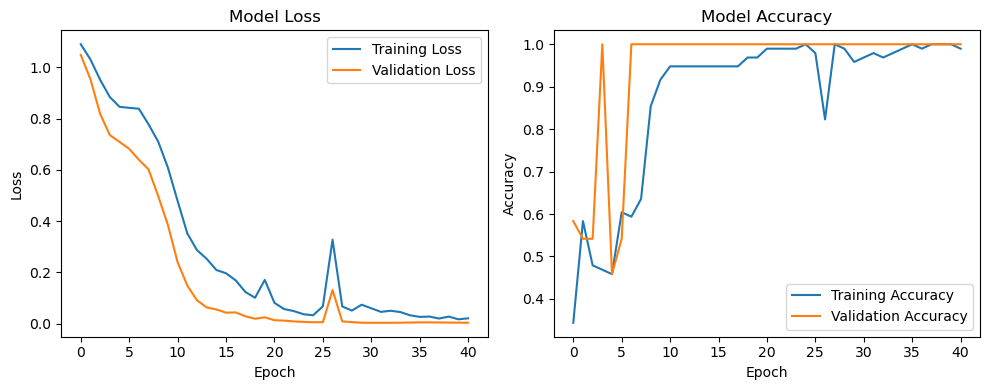

In [7]:
# Plot training history
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## Save Model

In [8]:
# Save model
model.save('dataset/processed/lstm_model.keras')
print('Model saved to dataset/processed/lstm_model.keras')

Model saved to dataset/processed/lstm_model.keras


## Summary

**LSTM Model Results:**
- Architecture: Bidirectional LSTM with embedding layer
- Task: Multi-class classification (positive, neutral, negative sentiment)
- Performance: Accuracy on test set

**Key Concepts Demonstrated:**
- Recurrent Neural Networks (RNNs)
- Long Short-Term Memory (LSTM)
- Bidirectional processing
- Text classification with word embeddings